In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
# Read input image
img = cv2.imread('HappyFish.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image not loaded properly")

In [5]:
# 1. Compute 2D Fourier Transform and shift
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-9)

In [7]:
# 2. Shift low frequency components to center (already done via fftshift)

# 3. Create Ideal Low Pass Filter
rows, cols = img.shape
crow, ccol = rows//2, cols//2
cutoff_radius = 30

y, x = np.ogrid[:rows, :cols]
mask_low = (x - ccol)**2 + (y - crow)**2 <= cutoff_radius**2
mask_low = mask_low.astype(np.float32)

In [8]:
# 4. Multiply with filter and smoothen
fshift_low = fshift * mask_low

In [9]:
# 6. Decentralize frequencies back
f_ishift_low = np.fft.ifftshift(fshift_low)

In [10]:
# 7. Inverse Fourier Transform
img_low = np.fft.ifft2(f_ishift_low)
img_low = np.abs(img_low)

In [11]:
# 8. Create Ideal High Pass Filter
mask_high = 1 - mask_low

In [12]:
# 9. Apply high pass filtering
fshift_high = fshift * mask_high

In [13]:
# 10. Decentralize and inverse transform
f_ishift_high = np.fft.ifftshift(fshift_high)
img_high = np.fft.ifft2(f_ishift_high)
img_high = np.abs(img_high)

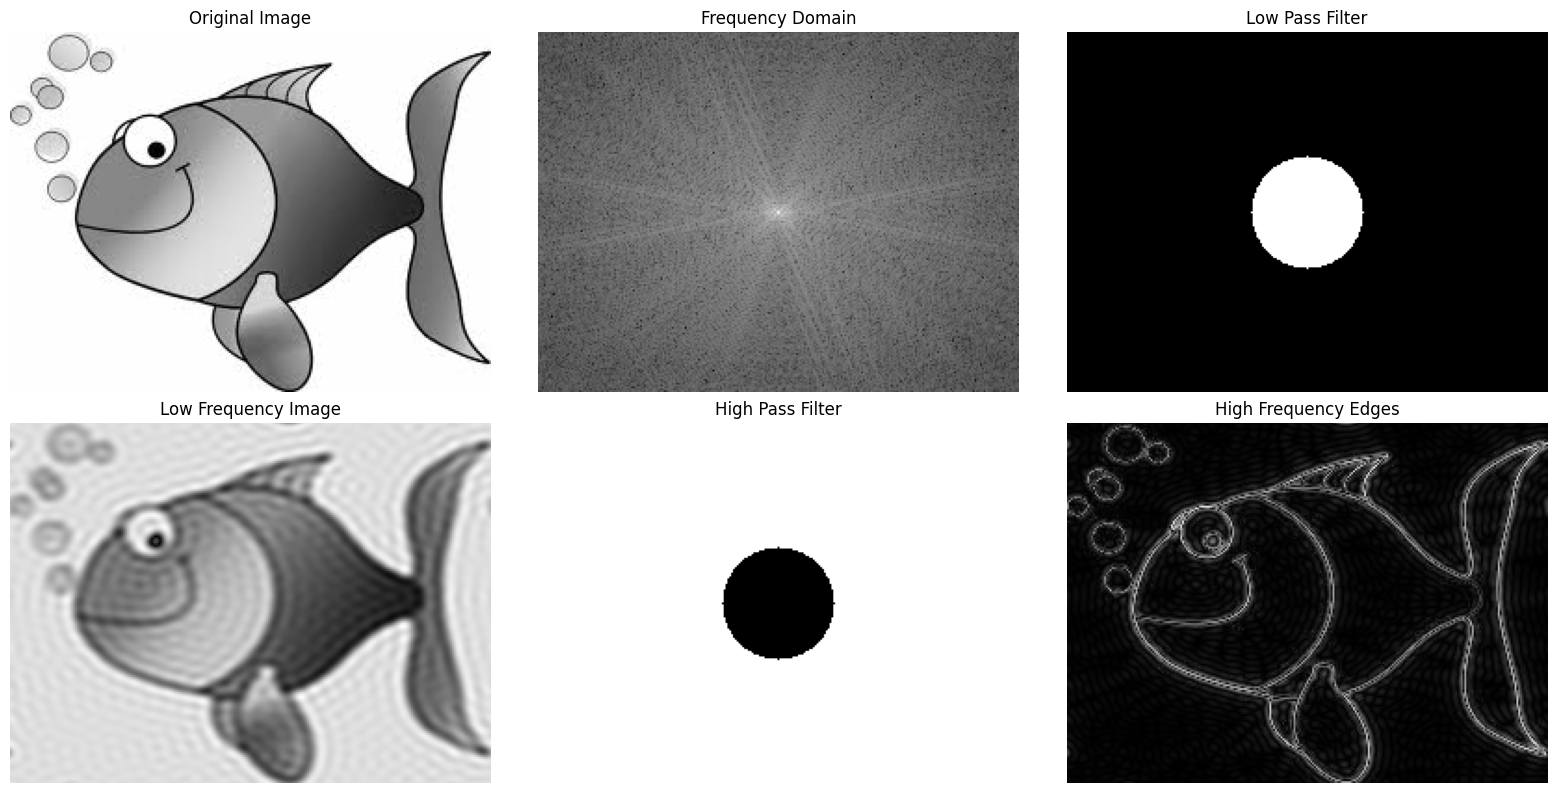

In [14]:
# Plot results
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(2, 3, 2), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Frequency Domain'), plt.axis('off')

plt.subplot(2, 3, 3), plt.imshow(mask_low, cmap='gray')
plt.title('Low Pass Filter'), plt.axis('off')

plt.subplot(2, 3, 4), plt.imshow(img_low, cmap='gray')
plt.title('Low Frequency Image'), plt.axis('off')

plt.subplot(2, 3, 5), plt.imshow(mask_high, cmap='gray')
plt.title('High Pass Filter'), plt.axis('off')

plt.subplot(2, 3, 6), plt.imshow(img_high, cmap='gray')
plt.title('High Frequency Edges'), plt.axis('off')

plt.tight_layout()
plt.show()


# 5. Justification: The low pass filter removes high frequencies by setting
# all frequencies outside the cutoff radius to zero. This eliminates rapid
# intensity changes (edges) while preserving smooth variations.

# The high pass filter does the opposite, removing low frequencies and
# preserving only the edges and rapid intensity changes.